# AV Blocking Incidents: Frequency, Hazard Classification, and Risk-Matrix Placement

**Authors:** Jonathan Wilson and Chujiang (CJ) Wu

Primary analysis notebook. It reads the raw DEM workbooks in `data/`, runs every
step of the analysis, and exports figures, tables, and key numbers to
`project-site/assets/` and `project-site/_variables.yml`, which the Quarto paper
and slides reference. Re-running this notebook top to bottom regenerates all of them.

**Data credit.** The incident log comes from the San Francisco Department of
Emergency Management (DEM). Dr. Missy Cummings did most of the difficult original
cleaning and coding of these records; this analysis builds on that work.

**Sections**

1. Data loading, cleaning, and quality
2. Data engineering from the secondary sheets
3. Descriptive statistics
4. Hazard taxonomy and narrative classification
5. Impact (consequence) scoring
6. Frequency estimation
7. Is anything changing over time? (non-parametric trend tests)
8. Risk matrix
9. Sensitivity analysis

In [1]:
%matplotlib inline
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from av_blocking import analysis, config, data, frequency as fq, nlp, plotting as P
from av_blocking import risk_matrix as rm, severity as sv, taxonomy as tx, trends as tr
from av_blocking.export import save_fig, save_table, save_text, save_var, save_vars

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200, "display.max_colwidth", 110, "display.max_columns", 40)
P.set_style()
config.VARIABLES_FILE.unlink(missing_ok=True)   # rebuild the paper's variables from scratch

def r(x, d=2):
    return float(round(float(x), d))

def fmt_p(p):
    return "< 0.001" if p < 0.001 else f"{p:.3f}"

HAZ_LABEL = {h.code: f"{h.code} {h.short}" for h in tx.HAZARDS}

## 1. Data loading, cleaning, and quality

The primary source is the `DEM Incidents` sheet of `AV-Brick-Report.xlsx`.
Cleaning steps (all in `av_blocking.data`):

* Start/clear times arrive as a mix of Excel time objects and `"H:MM"` strings.
  Both are parsed to minutes after midnight.
* Duration is computed as clear minus start, **modulo 1,440 minutes**, so events that cross
  midnight come out positive. The workbook's own formula did this for only some rows.
* Narratives have their whitespace normalized and are flagged when missing or likely
  **truncated**. Many were cut at about 45–60 characters by the export.
* The operator (Waymo or Zoox) is extracted from the narrative. A missing AV count is
  treated as "at least one" for the clustering rule.

In [2]:
df = analysis.prepare()
days = data.observation_days()
T = float(days.sum())
w = df[df["in_covered_window"]].copy()     # incidents inside fully covered months

quality = pd.DataFrame({
    "Quantity": ["Incidents (primary sheet)", "Date range", "Months present",
                 "Covered months used for rates", "Covered exposure (days)",
                 "Incidents in covered months", "Narrative missing", "Narrative likely truncated",
                 "AV count missing", "Durations crossing midnight", "Operator = Waymo / Zoox / unstated"],
    "Value": [len(df), f"{df.date.min():%Y-%m-%d} to {df.date.max():%Y-%m-%d}",
              ", ".join(sorted(df.month.unique())), ", ".join(days.index), int(T), len(w),
              int(df.narrative_missing.sum()),
              f"{int(df.narrative_truncated.sum())} ({df.narrative_truncated.mean():.0%})",
              int(df.n_avs_missing.sum()), int(df.crosses_midnight.sum()),
              " / ".join(str(int((df.operator == o).sum())) for o in ["Waymo", "Zoox", "Unknown"])],
})
display(quality)
save_table(quality, "tbl-data-quality", "Data inventory and quality checks for the primary DEM sheet.")
save_vars({"n_incidents": len(df), "n_window": len(w), "window_days": int(T),
           "first_date": f"{df.date.min():%B %-d, %Y}", "last_date": f"{df.date.max():%B %-d, %Y}",
           "n_truncated": int(df.narrative_truncated.sum()),
           "pct_truncated": f"{df.narrative_truncated.mean():.0%}",
           "n_missing_narrative": int(df.narrative_missing.sum()),
           "n_months_covered": len(days)}, "data")

,Quantity,Value
0,Incidents (primary sheet),123
1,Date range,2025-02-01 to 2025-10-31
2,Months present,"2025-02, 2025-03, 2025-06, 2025-07, 2025-08, 2025-09, 2025-10"
3,Covered months used for rates,"2025-03, 2025-06, 2025-07, 2025-08, 2025-09, 2025-10"
4,Covered exposure (days),184
5,Incidents in covered months,120
6,Narrative missing,1
7,Narrative likely truncated,83 (67%)
8,AV count missing,3
9,Durations crossing midnight,3


**Coverage gaps matter.** February has only three incidents, all on Feb 1–3, and April–May
are missing entirely. Those are gaps in the log, not months with no incidents. Rates and
trends therefore use only the six fully covered months (March and June–October, 184 days).
The three February incidents still count toward the classification and impact analysis.
Section 9 shows that the conclusions hold if February is included.

In [3]:
print(df.groupby("month").agg(n=("incident_id", "size"), first=("date", "min"), last=("date", "max"),
                              truncated=("narrative_truncated", "mean")).round({"truncated": 2}))

          n      first       last  truncated
month                                       
2025-02   3 2025-02-01 2025-02-03       0.00
2025-03  24 2025-03-01 2025-03-30       0.96
2025-06  17 2025-06-03 2025-06-27       1.00
2025-07  18 2025-07-07 2025-07-25       1.00
2025-08  25 2025-08-01 2025-08-31       0.16
2025-09  11 2025-09-11 2025-09-30       0.18
2025-10  25 2025-10-05 2025-10-31       0.76


## 2. Data engineering from the secondary sheets

`AV-Brick-Report-analyzed.xlsx` adds:

| Sheet | Useful content | How it is used here |
|---|---|---|
| `DEM Incidents` (analyzed copy) | AV-company ETA, other parties, emergency-responder-impact and transit-impact flags; 8 extra incidents with narratives but no times | Joined on (date, location): all 123 primary rows match. Extra incidents feed a frequency sensitivity check. |
| `DEM Incidents Quant` | Hand-coded neighborhood zone (1–10), multi-AV flag, 4-hour time-of-day bin, >20 / >40-minute flags | Neighborhood joined (119/123 match). The other derived columns are recomputed from source fields. |
| `plots and stats` | Monthly duration mean/SD/median, a 6-group skewness/normality/rank-sum table (a Kruskal–Wallis setup), and a March-vs-October Mann–Whitney test (W = 377, p = 0.063) | Replicated in Section 7, then extended with trend-specific tests. |

The analyzed sheet's emergency-responder flag marks *responder involvement* (for example,
police called to direct traffic around a stalled AV), not obstruction of an emergency
response. So it is kept as a separate feature and does not define hazard H2.

In [4]:
supp = data.supplementary_incidents()
eng = pd.DataFrame({
    "Feature": ["Neighborhood zone assigned", "ETA provided by AV company", "Emergency-responder flag = Y",
                "Transit-impact flag = Y", "Supplementary incidents (narrative, no times)"],
    "Count": [int((df.zone.notna()).sum()), int(df.eta_min.notna().sum()), int(df.er_impact_flag.sum()),
              int(df.transit_impact_flag.sum()), len(supp)],
})
display(eng)
print("ETA (minutes) when given:", df.eta_min.describe().round(1).to_dict())
display(supp)
save_var("data.n_supplementary", len(supp))

,Feature,Count
0,Neighborhood zone assigned,119
1,ETA provided by AV company,22
2,Emergency-responder flag = Y,6
3,Transit-impact flag = Y,4
4,"Supplementary incidents (narrative, no times)",8


ETA (minutes) when given: {'count': 22.0, 'mean': 17.1, 'std': 11.0, 'min': 1.0, '25%': 12.0, '50%': 14.5, '75%': 20.0, 'max': 45.0}


,date,month,location,narrative,n_avs_filled
0,2025-02-01,2025-02,I 280SB SAN JOSE ON,Req from CHP to have SFPD resp to assist with removing disabled Waymo AV that is completely blocking the r...,1
1,2025-08-15,2025-08,"7TH ST/BRYANT ST, SF","RP reporting an unoccpyd Zoox AV driving erratically, had its left turn signal on but kept turning right a...",1
2,2025-10-15,2025-10,"78 ANNIE ST,",Waymo blking traffic rep on 911 txd to 0123 non-emer,1
3,2025-10-16,2025-10,TURK ST/VAN NESS,Waymo AV drove into the middle of active 518 H/R,1
4,2025-10-20,2025-10,"FOLSOM ST/CRESCENT AV,",Two Muni Coaches stuck in traffic per RP it is due to,1
5,2025-10-22,2025-10,"MARKET ST/CORBETT AV,",Multi veh inj accident Waymo AV drove into the scen,1
6,2025-10-31,2025-10,"CASTRO ST/19TH ST,",Critical Mass Waymo advd to to avoid the area due to,1
7,2025-10-31,2025-10,"1324 GRANT AV,",Waymo stuck and blkng traffic for the last 25 mins Jag,1


## 3. Descriptive statistics

In [5]:
dur = w["duration_min"]
med, med_lo, med_hi = tr.bootstrap_median_ci(dur)
desc = pd.DataFrame({
    "Statistic": ["n", "Mean", "SD", "Median (bootstrap 95% CI)", "IQR", "90th percentile", "Max",
                  "Share > 20 min", "Share > 40 min", "Share >= 60 min", "Multi-AV incidents"],
    "Duration (minutes)": [len(dur), f"{dur.mean():.1f}", f"{dur.std():.1f}",
                           f"{med:.0f} ({med_lo:.0f}-{med_hi:.0f})",
                           f"{dur.quantile(.25):.0f}-{dur.quantile(.75):.0f}", f"{dur.quantile(.9):.0f}",
                           f"{dur.max():.0f}", f"{(dur > 20).mean():.0%}", f"{(dur > 40).mean():.0%}",
                           f"{(dur >= 60).mean():.0%}", f"{int(w.multi_av.sum())} ({w.multi_av.mean():.0%})"],
})
display(desc)
save_table(desc, "tbl-duration-summary", "Summary statistics for incident duration (covered months, n = 120).")
save_vars({"median": int(med), "median_lo": int(med_lo), "median_hi": int(med_hi), "mean": r(dur.mean(), 1),
           "p90": int(dur.quantile(.9)), "max": int(dur.max()), "iqr_lo": int(dur.quantile(.25)),
           "iqr_hi": int(dur.quantile(.75)), "pct_ge60": f"{(dur >= 60).mean():.0%}",
           "pct_multi": f"{w.multi_av.mean():.0%}", "n_multi": int(w.multi_av.sum())}, "dur")

by_month = w.groupby("month")["duration_min"].agg(n="size", mean="mean", sd="std", median="median").round(1)
by_month["incidents_per_30d"] = (by_month["n"] / days * 30).round(1)
display(by_month)
save_table(by_month.reset_index(), "tbl-monthly", "Incidents and duration by covered month.")

,Statistic,Duration (minutes)
0,n,120
1,Mean,52.1
2,SD,76.7
3,Median (bootstrap 95% CI),23 (17-36)
4,IQR,9-63
5,90th percentile,126
6,Max,603
7,Share > 20 min,52%
8,Share > 40 min,38%
9,Share >= 60 min,28%


,n,mean,sd,median,incidents_per_30d
month,,,,,
2025-03,24,61.5,130.1,15.0,23.2
2025-06,17,54.8,56.8,39.0,17.0
2025-07,18,40.4,45.3,18.0,17.4
2025-08,25,32.6,40.0,17.0,24.2
2025-09,11,68.6,84.9,47.0,11.0
2025-10,25,61.9,62.3,46.0,24.2


PosixPath('/home/jon/Documents/grad_school/ai-risk/AV_Brick/project-site/assets/tables/tbl-monthly.md')

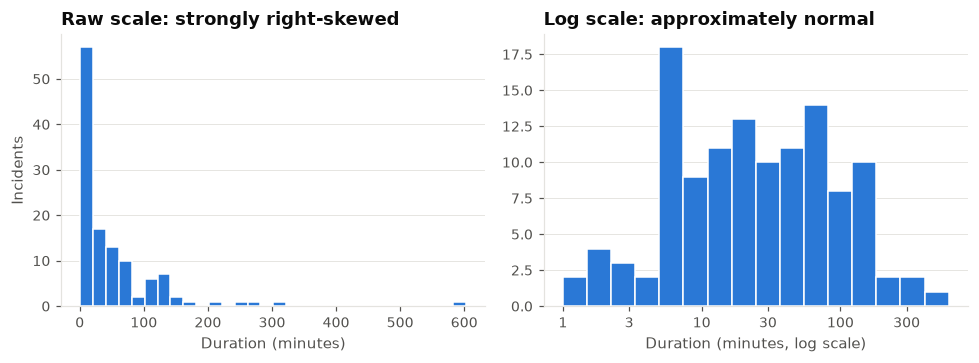

,scale,n,skewness,excess_kurtosis,shapiro_W,p_value
0,raw minutes,120,3.9106,21.9030,0.6141,0.0000
1,log minutes,120,-0.0949,-0.5875,0.9881,0.3796


In [6]:
fig, _ = P.duration_distribution_plot(w["duration_min"])
save_fig(fig, "fig-duration-dist"); plt.show()
display(tr.normality(w["duration_min"]).round(4))

Raw durations are strongly right-skewed and heavy-tailed: skewness ≈ 3.9, excess kurtosis
≈ 22, Shapiro–Wilk p < 10⁻¹⁵. Log-durations look approximately normal (Shapiro–Wilk
p ≈ 0.38). Durations are therefore close to log-normal. Rank-based tests are the primary
inference, and tests on log-durations serve as a parametric cross-check.

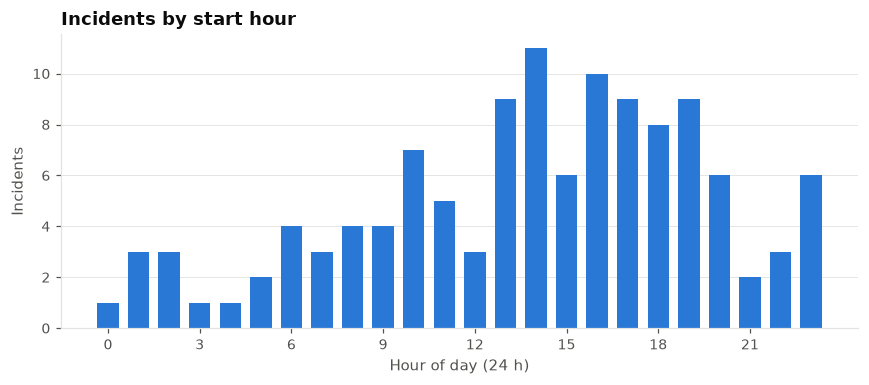

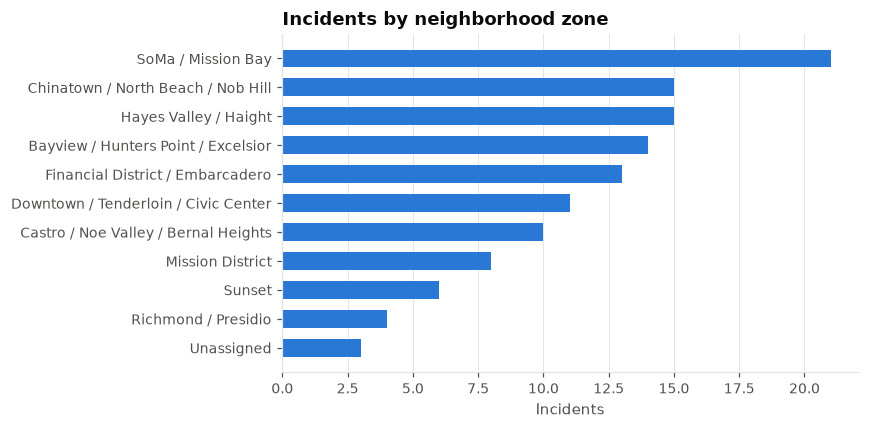

Weekday uniformity chi-square p = 0.565
Hour-of-day uniformity over 6 x 4-h bins p = < 0.001


In [7]:
hours = w["start_hour"].value_counts().reindex(range(24), fill_value=0)
fig, ax = P.count_bar_plot(hours, "Incidents by start hour", "Hour of day (24 h)")
ax.set_xticks(range(0, 24, 3), range(0, 24, 3))
save_fig(fig, "fig-hour"); plt.show()

nb = w["neighborhood"].value_counts()
fig, _ = P.count_bar_plot(nb, "Incidents by neighborhood zone", "", horizontal=True, figsize=(8, 4))
save_fig(fig, "fig-neighborhood"); plt.show()

wd = w["weekday"].value_counts().reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday",
                                          "Saturday", "Sunday"], fill_value=0)
from scipy import stats
print("Weekday uniformity chi-square p =", round(stats.chisquare(wd).pvalue, 3))
print("Hour-of-day uniformity over 6 x 4-h bins p =",
      fmt_p(stats.chisquare(w["start_hour"].dropna().astype(int).floordiv(4).value_counts()
                            .reindex(range(6), fill_value=0)).pvalue))

## 4. Hazard taxonomy and narrative classification

### 4.1 Taxonomy design

A **hazard** here is defined by its *consequence*: what the immobilized AV obstructed or put
at risk. Two principles make the classes defensible:

1. **Separate consequence from cause.** Why the AV stopped (vehicle fault, signal outage,
   passenger, routing edge case) is recorded on a separate *contributing-cause* axis.
   Mixing the two axes produces overlapping, non-comparable categories.
2. **Mutually exclusive and exhaustive by precedence.** An incident can match several
   descriptions, for example a fire scene that also has two AVs stuck. Each incident takes
   the *most severe* matching class (H1 > H2 > … > H7), and H7 is the default. Every
   incident then counts exactly once, and frequencies add up to the total.

H6 (multi-AV clustering) is a hazard class in its own right because simultaneous
immobilization of several AVs at one site points to a **common-mode (fleet-level) failure**:
shared software, maps, or connectivity. That is a different mechanism from a single
vehicle's fault, with a disproportionate loss of road capacity.

In [8]:
tax = tx.taxonomy_table()
display(tax)
save_table(tax, "tbl-taxonomy", "Consequence-based hazard taxonomy (assigned by severity-first precedence).")
causes = pd.DataFrame(list(tx.CAUSES.items()), columns=["Code", "Contributing cause"])
display(causes)
save_table(causes, "tbl-causes", "Contributing-cause codes (mechanism axis).")

,Code,Hazard,Definition
0,H1,AV-involved collision,"The AV made (or was reported to make) contact with another road user, vehicle, or animal, leaving the AV o..."
1,H2,Emergency-response obstruction,"The AV obstructed an emergency response (medics, fire, police) or became stuck inside an active emergency ..."
2,H3,Transit / rail obstruction,"The AV blocked a public-transit vehicle, lane, or track (Muni bus or rail, cable car) or a railroad track."
3,H4,Pedestrian / accessibility obstruction,"The AV blocked a crosswalk, curb ramp, or bike lane, pushing vulnerable road users into traffic."
4,H5,Occupant-related immobilization,"A passenger condition or action immobilized the AV: unresponsive/asleep rider, occupant trapped or calling..."
5,H6,Multi-AV clustering / gridlock,"Two or more AVs immobilized together at one location (a common-mode, fleet-level failure) with none of the..."
6,H7,Single-AV traffic obstruction,"One AV stalled in a travel lane, intersection, or roadway, obstructing general traffic only. Default class."


,Code,Contributing cause
0,collision,AV collision / contact
1,external_scene,"External event or scene (fire, crash, protest, police activity)"
2,infrastructure,Infrastructure failure (signal or power outage)
3,occupant,Passenger condition or action
4,vehicle_fault,"Vehicle fault (hardware, battery, tire, sensor damage)"
5,tampering,Tampering / vandalism
6,maneuver,"Maneuver or routing edge case (turn, parking lot, cul-de-sac, queue)"
7,unstated,Unstated (stalled/stuck with no cause given)


PosixPath('/home/jon/Documents/grad_school/ai-risk/AV_Brick/project-site/assets/tables/tbl-causes.md')

### 4.2 Method selection

| Approach | Needs | Fit for this data |
|---|---|---|
| Keyword / regex rules over dispatcher shorthand | Domain reading only | **Selected.** Transparent, auditable, deterministic, and works on truncated text. |
| Supervised TF-IDF + logistic regression / XGBoost | Labeled training data, ideally hundreds per class | Evaluated below. With 4–17 examples in the rare classes it cannot learn them. |
| Fine-tuned transformer (BERT-type) | Even more labeled data | Not justified at n = 123. It would overfit, and the result would not be auditable. |
| Zero-shot NLI transformers (BART-large-MNLI, DeBERTa-v3-large NLI) | No labels; large model | Evaluated as independent cross-checks (optional extra). |
| Sentence-embedding similarity (mxbai-embed-large) | No labels; mid-size model | Evaluated as a cheaper pretrained baseline (optional extra). |

To evaluate any method, an independent reference is needed. Every narrative was read
and hand-coded (`data/labels/manual_hazard_labels.csv`, with notes on ambiguous cases).

In [9]:
from sklearn.metrics import cohen_kappa_score, confusion_matrix
agree = (df.hazard == df.manual_hazard).mean()
kappa = cohen_kappa_score(df.hazard, df.manual_hazard)
print(f"Rule vs manual agreement: {agree:.1%}, Cohen's kappa = {kappa:.3f}")
dis = df.loc[df.hazard != df.manual_hazard, ["incident_id", "hazard", "manual_hazard", "narrative", "manual_note"]]
display(dis)
save_table(dis.rename(columns={"incident_id": "Incident", "hazard": "Rule", "manual_hazard": "Manual",
                               "narrative": "Narrative", "manual_note": "Note"}),
           "tbl-disagreements", "Incidents where the rule classifier and the manual audit disagree.")
multi = df["n_hazard_matches"].value_counts().sort_index()
print("Number of non-default hazard rules matched per incident:", multi.to_dict())
save_vars({"agree": f"{agree:.1%}", "kappa": r(kappa, 2), "n_disagree": len(dis),
           "n_multi_match": int((df.n_hazard_matches >= 2).sum())}, "taxon")

Rule vs manual agreement: 99.2%, Cohen's kappa = 0.987


,incident_id,hazard,manual_hazard,narrative,manual_note
65,INC-066,H2,H1,Traffic hazard due to a veh accident..need PD for traffic control..tow truck en route no eta..PD resp..Way...,Ambiguous: 'veh accident' with the Waymo subsequently moved and a tow en route suggests AV involvement.


Number of non-default hazard rules matched per incident: {0: 72, 1: 43, 2: 8}


The rules were written by the same analyst who coded the audit labels, after reading the
narratives, so this agreement is an internal-consistency check, not an independent
validation. The remaining disagreement is a real ambiguity: a crash scene where it is unclear whether the AV itself was involved. The blind second coder below addresses the single-analyst problem.

#### Blind second-coder cross-check (LLM)

The rules and the manual labels come from the same analyst. As an independent cross-check,
a second coder of a different model family, OpenAI's Codex (based on GPT-6; exact build not
exposed), labeled all 123 incidents *blind*. It saw only a label-free coding packet,
`data/labels/blind_audit/`: the narratives and AV counts (`coding_sheet.csv`) and the
taxonomy definitions with the precedence rule and a shorthand glossary (`CODING_GUIDE.md`).
It reported opening no other file, and the repository confirms it modified nothing else.
It was told to read each narrative and judge it, not to use keyword scripts, and to give a
confidence level and a short rationale for each label.

This is an *LLM* second coder, not human validation. Agreement between two language models
can partly reflect shared training rather than independent judgment.

In [10]:
from statsmodels.stats.inter_rater import aggregate_raters, fleiss_kappa

cx = pd.read_csv(config.LLM_AUDIT_LABELS).rename(columns={"hazard": "codex", "confidence": "codex_confidence",
                                                          "rationale": "codex_rationale"})
assert cx.incident_id.tolist() == df.incident_id.tolist() and cx.codex.isin(tx.HAZARD_CODES).all()
aud = df[["incident_id", "narrative", "hazard", "manual_hazard", "manual_note"]].merge(cx, on="incident_id")

raters = {"Manual audit": "manual_hazard", "Rules": "hazard", "LLM second coder (Codex)": "codex"}
pairs = [("LLM second coder (Codex)", "Manual audit"), ("LLM second coder (Codex)", "Rules"),
         ("Manual audit", "Rules")]
agreement = pd.DataFrame([{"Coder A": a, "Coder B": b,
                           "Agree": f"{(aud[raters[a]] == aud[raters[b]]).sum()}/{len(aud)}",
                           "Percent": f"{(aud[raters[a]] == aud[raters[b]]).mean():.1%}",
                           "Cohen kappa": round(cohen_kappa_score(aud[raters[a]], aud[raters[b]]), 3)}
                          for a, b in pairs])
fk = fleiss_kappa(aggregate_raters(aud[list(raters.values())].values)[0])
agreement.loc[len(agreement)] = ["All three", "(Fleiss)", "", "", round(fk, 3)]
display(agreement)
save_table(agreement, "tbl-coder-agreement", "Inter-coder agreement on hazard labels (n = 123).")

# Resolution of each disagreement (labels were kept unchanged; see notes)
RESOLUTION = {
    "INC-040": "Kept H3. The text does not say the AV blocked transit, but the analyzed sheet's transit-impact flag is Y.",
    "INC-041": "Kept H5. An occupant inside a stopped AV; whether they caused the stop is not stated. Either code is defensible.",
    "INC-066": "Kept H1 (manual) / H2 (rules). Already flagged as ambiguous; Codex sided with the rules.",
    "INC-112": "Kept H3. Truncated before saying what was blocked; Codex's stricter H7 is also defensible.",
}
dis2 = aud.loc[aud.codex != aud.manual_hazard, ["incident_id", "narrative", "manual_hazard", "hazard", "codex",
                                                 "codex_confidence", "codex_rationale"]].copy()
dis2["Resolution"] = dis2.incident_id.map(RESOLUTION).fillna("Not reviewed")
dis2.columns = ["Incident", "Narrative", "Manual", "Rules", "Codex", "Codex confidence", "Codex rationale", "Resolution"]
display(dis2)
save_table(dis2, "tbl-coder-disagreements",
           "Incidents where the LLM second coder disagrees with the manual audit, with its rationale and the resolution.")
low = aud.loc[aud.codex_confidence == "low", "incident_id"].tolist()
print("Codex low-confidence incidents:", low)
print("  ...of which flagged ambiguous in the manual notes:", [i for i in low if aud.set_index("incident_id").manual_note[i]])
save_vars({"cx_manual_kappa": r(cohen_kappa_score(aud.codex, aud.manual_hazard)),
           "cx_rules_kappa": r(cohen_kappa_score(aud.codex, aud.hazard)),
           "cx_manual_agree": int((aud.codex == aud.manual_hazard).sum()),
           "cx_rules_agree": int((aud.codex == aud.hazard).sum()),
           "fleiss": r(fk, 3), "cx_n_disagree": len(dis2), "cx_n_low": len(low),
           "cx_n_low_in_dis": int(dis2["Codex confidence"].eq("low").sum())}, "taxon")

,Coder A,Coder B,Agree,Percent,Cohen kappa
0,LLM second coder (Codex),Manual audit,119/123,96.7%,0.947
1,LLM second coder (Codex),Rules,120/123,97.6%,0.960
2,Manual audit,Rules,122/123,99.2%,0.987
3,All three,(Fleiss),,,0.965


,Incident,Narrative,Manual,Rules,Codex,Codex confidence,Codex rationale,Resolution
39,INC-040,Traffic lights are out..hazard for Muni trains..DPT trying,H3,H3,H7,low,"Traffic lights were out and Muni trains faced a hazard, but AV obstruction of transit is not stated.","Kept H3. The text does not say the AV blocked transit, but the analyzed sheet's transit-impact flag is Y."
40,INC-041,Subj inside of a Waymo rtl..AV stationary LP 76962Y3,H5,H5,H7,medium,"A subject was inside a stationary Waymo, but no occupant condition or action causing immobilization is sta...",Kept H5. An occupant inside a stopped AV; whether they caused the stop is not stated. Either code is defen...
65,INC-066,Traffic hazard due to a veh accident..need PD for traffic control..tow truck en route no eta..PD resp..Way...,H1,H2,H2,low,"A vehicle accident required traffic control, suggesting an active crash scene; the AV relation to that sce...",Kept H1 (manual) / H2 (rules). Already flagged as ambiguous; Codex sided with the rules.
111,INC-112,Waymo is near the railroad track blocking the,H3,H3,H7,low,The Waymo was near a railroad track and blocking an unspecified object; the truncation does not establish ...,Kept H3. Truncated before saying what was blocked; Codex's stricter H7 is also defensible.


Codex low-confidence incidents: ['INC-040', 'INC-043', 'INC-050', 'INC-055', 'INC-066', 'INC-108', 'INC-112']
  ...of which flagged ambiguous in the manual notes: ['INC-043', 'INC-055', 'INC-066', 'INC-108', 'INC-112']


The learned models avoid the in-sample optimism because they are scored on held-out folds:

Pretrained models found: ['Zero-shot BART-large-MNLI', 'Zero-shot DeBERTa-v3-large NLI', 'Embedding similarity (mxbai-embed-large)']


,method,family,macro_F1,macro_F1_sd,accuracy,kappa
0,Majority class + count rule,Baseline,0.249,NaN,0.724,0.433
1,TF-IDF + XGBoost (CV),Supervised (cross-validated),0.320,0.074,0.735,0.477
2,TF-IDF + logistic regression (CV),Supervised (cross-validated),0.470,0.085,0.774,0.582
3,Zero-shot BART-large-MNLI,"Pretrained, no training",0.396,NaN,0.585,0.378
4,Zero-shot DeBERTa-v3-large NLI,"Pretrained, no training",0.323,NaN,0.504,0.279
5,Embedding similarity (mxbai-embed-large),"Pretrained, no training",0.620,NaN,0.691,0.563
6,"LLM + coding guide (Codex, GPT-6-based)",LLM with coding guide,0.946,NaN,0.967,0.947
7,Rule-based (selected; in-sample),Rules,0.978,NaN,0.992,0.987


,n (manual),TF-IDF + logistic regression,TF-IDF + XGBoost,Zero-shot BART-large-MNLI,Zero-shot DeBERTa-v3-large NLI,Embedding similarity (mxbai-embed-large),"LLM + coding guide (Codex, GPT-6-based)",Rule-based
H1 Collision,7,0.67,0.40,0.31,0.26,0.62,0.92,0.92
H2 Emergency obstruction,6,0.00,0.00,0.33,0.00,0.67,0.92,0.92
H3 Transit obstruction,8,0.46,0.22,0.22,0.21,0.47,0.86,1.00
H4 Ped/accessibility,4,0.33,0.00,0.00,0.40,0.43,1.00,1.00
H5 Occupant-related,9,0.46,0.00,0.50,0.20,0.67,0.94,1.00
H6 Multi-AV gridlock,17,0.94,0.94,0.67,0.48,0.71,1.00,1.00
H7 Single-AV obstruction,72,0.86,0.83,0.74,0.71,0.78,0.98,1.00


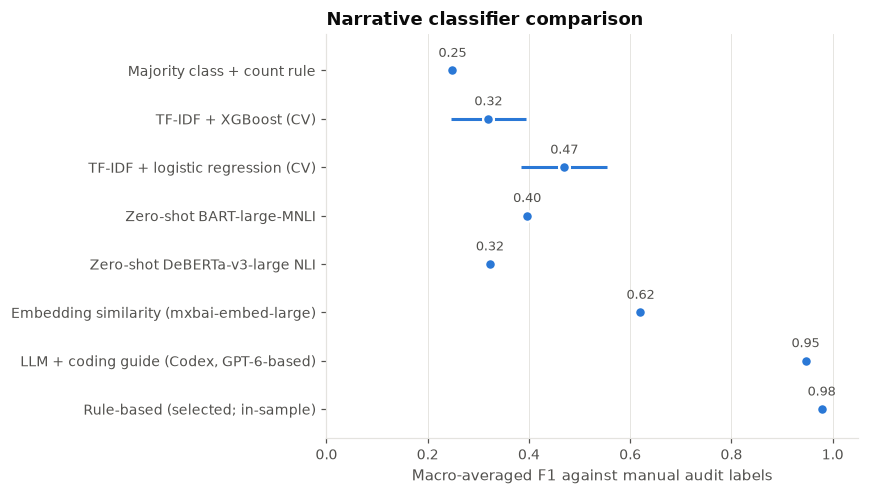

,Manual audit,Zero-shot BART-large-MNLI,Zero-shot DeBERTa-v3-large NLI,Embedding similarity (mxbai-embed-large)
H1 Collision,7,38,39,6
H2 Emergency obstruction,6,6,5,9
H3 Transit obstruction,8,1,11,22
H4 Ped/accessibility,4,2,1,10
H5 Occupant-related,9,3,1,12
H6 Multi-AV gridlock,17,10,8,11
H7 Single-AV obstruction,72,63,58,53


In [11]:
folds, pooled = nlp.cross_validate_models(df)
cv = folds.groupby("model")[["accuracy", "macro_F1", "kappa"]].agg(["mean", "std"])
base = nlp.majority_baseline(df)
rules = nlp._scores(df.manual_hazard, df.hazard)
# Pretrained models with no training on this data (cached; `make zeroshot` re-runs them)
pretrained = nlp.load_all_zeroshot(df)
print("Pretrained models found:", list(pretrained))

def row(method, s, sd=np.nan, family=""):
    return {"method": method, "family": family, "macro_F1": s["macro_F1"], "macro_F1_sd": sd,
            "accuracy": s["accuracy"], "kappa": s["kappa"]}

rows = [row("Majority class + count rule", base, family="Baseline")]
for m in cv.index:
    rows.append(row(m + " (CV)", {k: cv.loc[m, (k, "mean")] for k in ["macro_F1", "accuracy", "kappa"]},
                    sd=cv.loc[m, ("macro_F1", "std")], family="Supervised (cross-validated)"))
for name, pred in pretrained.items():
    rows.append(row(name, nlp._scores(df.manual_hazard, pred), family="Pretrained, no training"))
# Frontier LLM given the written coding guide (the blind second coder from 4.1)
LLM_NAME = "LLM + coding guide (Codex, GPT-6-based)"
llm_pred = pd.read_csv(config.LLM_AUDIT_LABELS).set_index("incident_id").loc[df.incident_id, "hazard"].values
rows.append(row(LLM_NAME, nlp._scores(df.manual_hazard, llm_pred), family="LLM with coding guide"))
rows.append(row("Rule-based (selected; in-sample)", rules, family="Rules"))
comp = pd.DataFrame(rows)
display(comp.round(3))
save_table(comp.round(3).fillna("—"), "tbl-classifiers",
           "Narrative classifiers scored against the manual audit labels (supervised models: mean and SD over 4-fold x 5 repeated stratified CV; pretrained models and the LLM use no training data; the LLM was given the written coding guide).")

per_class = pd.DataFrame({m: nlp.per_class_f1(df.manual_hazard, p) for m, p in pooled.items()})
for name, pred in pretrained.items():
    per_class[name] = nlp.per_class_f1(df.manual_hazard, pred)
per_class[LLM_NAME] = nlp.per_class_f1(df.manual_hazard, llm_pred)
per_class["Rule-based"] = nlp.per_class_f1(df.manual_hazard, df.hazard)
per_class.insert(0, "n (manual)", df.manual_hazard.value_counts().reindex(tx.HAZARD_CODES).values)
per_class.index = [HAZ_LABEL[c] for c in per_class.index]
display(per_class.round(2))
save_table(per_class.round(2).reset_index(names="Hazard"), "tbl-per-class-f1", "Per-class F1 by method.")

fig, _ = P.classifier_comparison_plot(comp)
save_fig(fig, "fig-classifiers"); plt.show()

# How often does each pretrained model predict each class? (over-prediction check)
pred_counts = pd.DataFrame({"Manual audit": df.manual_hazard.value_counts(),
                            **{n: pd.Series(p).value_counts() for n, p in pretrained.items()}}
                           ).reindex(tx.HAZARD_CODES).fillna(0).astype(int)
pred_counts.index = [HAZ_LABEL[c] for c in pred_counts.index]
display(pred_counts)
save_table(pred_counts.reset_index(names="Hazard"), "tbl-pretrained-counts",
           "Number of incidents assigned to each hazard by the manual audit and by each pretrained model.")

lr = cv.loc["TF-IDF + logistic regression", ("macro_F1", "mean")]
xg = cv.loc["TF-IDF + XGBoost", ("macro_F1", "mean")]
save_vars({"lr_f1": r(lr), "xgb_f1": r(xg), "base_f1": r(base["macro_F1"]), "rule_f1": r(rules["macro_F1"]),
           "lr_h2_f1": r(per_class.loc[HAZ_LABEL["H2"], "TF-IDF + logistic regression"])}, "ml")
for key, spec in nlp.PRETRAINED_MODELS.items():
    if spec["name"] in pretrained:
        s = comp.set_index("method").loc[spec["name"]]
        save_vars({"f1": r(s.macro_F1), "acc": r(s.accuracy), "kappa": r(s.kappa),
                   "h2_f1": r(per_class.loc[HAZ_LABEL["H2"], spec["name"]]),
                   "n_h1": int(pred_counts.loc[HAZ_LABEL["H1"], spec["name"]])}, f"ml.{key}")
s_llm = comp.set_index("method").loc[LLM_NAME]
save_vars({"f1": r(s_llm.macro_F1), "acc": r(s_llm.accuracy), "kappa": r(s_llm.kappa),
           "h2_f1": r(per_class.loc[HAZ_LABEL["H2"], LLM_NAME])}, "ml.llm")

#### Paired significance tests between classifiers

Every classifier labels the same 123 incidents, so comparisons are *paired*. Two tests:

* an **exact McNemar test** on which incidents each model gets right. Only the discordant
  incidents (one model right, the other wrong) carry information.
* a **paired percentile bootstrap** of the macro-F1 difference, resampling incidents with
  replacement 5,000 times.

The supervised models enter with their out-of-fold predictions, so every comparison uses
predictions made without seeing the incident being scored.

In [12]:
# Paired significance tests: are the differences between classifiers larger than chance?
# Both predictions are for the same 123 incidents, so the tests are paired:
#   * exact McNemar test on per-incident correctness (accuracy difference)
#   * paired percentile bootstrap of the macro-F1 difference (5,000 resamples)
# Supervised models use their out-of-fold predictions (first CV repeat).
named = {**{m + " (CV)": p for m, p in pooled.items()}, **pretrained}
pairs = []
bart_name = nlp.PRETRAINED_MODELS["bart"]["name"]
for key in ["deberta", "embedding"]:
    name = nlp.PRETRAINED_MODELS[key]["name"]
    if name in named and bart_name in named:
        pairs.append((name, bart_name))
for name in pretrained:
    pairs.append((name, "TF-IDF + logistic regression (CV)"))
ptests = []
for a, b in pairs:
    mc = nlp.mcnemar_exact(df.manual_hazard, named[a], named[b])
    bs = nlp.paired_bootstrap_f1(df.manual_hazard, named[a], named[b])
    ptests.append({"A": a, "B": b, "Only A correct": mc["only_a_correct"], "Only B correct": mc["only_b_correct"],
                   "McNemar p": fmt_p(mc["p_value"]),
                   "Macro-F1 A - B (95% CI)": f"{bs['delta_macro_F1']:+.2f} ({bs['ci_lo']:+.2f} to {bs['ci_hi']:+.2f})",
                   "CI excludes 0?": "Yes" if bs["ci_lo"] > 0 or bs["ci_hi"] < 0 else "No"})
ptests = pd.DataFrame(ptests)
display(ptests)
save_table(ptests, "tbl-classifier-tests",
           "Paired comparisons of classifiers on the same incidents: exact McNemar test on correctness and paired-bootstrap 95% CI for the macro-F1 difference.")
for _, t in ptests.iterrows():
    key = next(k for k, s in nlp.PRETRAINED_MODELS.items() if s["name"] == t["A"])
    tag = "vs_bart" if t["B"] == bart_name else "vs_lr"
    save_vars({"mcnemar_p": t["McNemar p"], "delta_f1": t["Macro-F1 A - B (95% CI)"]}, f"ml.{key}.{tag}")

,A,B,Only A correct,Only B correct,McNemar p,Macro-F1 A - B (95% CI),CI excludes 0?
0,Zero-shot DeBERTa-v3-large NLI,Zero-shot BART-large-MNLI,7,17,0.064,-0.07 (-0.20 to +0.05),No
1,Embedding similarity (mxbai-embed-large),Zero-shot BART-large-MNLI,28,15,0.066,+0.22 (+0.08 to +0.36),Yes
2,Zero-shot BART-large-MNLI,TF-IDF + logistic regression (CV),10,35,< 0.001,-0.14 (-0.29 to +0.02),No
3,Zero-shot DeBERTa-v3-large NLI,TF-IDF + logistic regression (CV),7,42,< 0.001,-0.21 (-0.39 to -0.03),Yes
4,Embedding similarity (mxbai-embed-large),TF-IDF + logistic regression (CV),19,31,0.119,+0.09 (-0.06 to +0.23),No


**Reading the comparison.**

* **Supervised models** do only modestly better than the majority class. Both score zero
  F1 on emergency obstruction, the rarest and most consequential class, and those rare
  classes drive the risk matrix.
* **Zero-shot NLI** needs no labels, but neither model beats logistic regression.
  BART-large-MNLI reaches macro-F1 ≈ 0.40. The larger, newer DeBERTa-v3 NLI model does
  slightly *worse*, at ≈ 0.32, though the difference from BART is not significant
  (bootstrap CI includes 0; McNemar p ≈ 0.06). Both label about 38 of 123 incidents
  "collision", against 7 in the audit. General-purpose NLI models are not trained on
  dispatcher shorthand (`blkng`, `ntfyd`, `LP`). A bigger model did not fix that.
* **Embedding similarity** is the best pretrained method: macro-F1 ≈ 0.62, significantly
  better than BART-MNLI (paired-bootstrap CI excludes 0). It is the only non-rule method
  with real skill on emergency obstruction (F1 ≈ 0.67). It edges out cross-validated
  logistic regression, though not significantly. It errs the other way from NLI, assigning
  too many incidents to transit (22 vs 8) and pedestrian/accessibility (10 vs 4).
* **A frontier LLM given the written coding guide** (the blind Codex second coder) is in a
  different league from the smaller pretrained models: macro-F1 ≈ 0.95 and κ ≈ 0.95
  against the manual audit. What makes the difference is the guide, which supplies the
  definitions, the precedence rule, and a shorthand glossary that the zero-shot models
  never see. It is used here as a validator, not as the production labeler (see 4.1, and
  the paper's discussion of why).
* **The rule set** remains far ahead. Its score is in-sample, but it is transparent,
  auditable, and needs no model download. It stays the defensible choice. If the log
  grows, the manual labels can seed a supervised model, and embedding similarity is a
  reasonable label-free starting point.

In [13]:
counts = df.hazard.value_counts().reindex(tx.HAZARD_CODES)
xt = pd.crosstab(df.hazard_name, df.cause_name).reindex([h.name for h in tx.HAZARDS])
display(xt)
save_table(xt.reset_index(names="Hazard"), "tbl-hazard-cause", "Hazard (consequence) by contributing cause (mechanism), all 123 incidents.")

cause_name,AV collision / contact,"External event or scene (fire, crash, protest, police activity)",Infrastructure failure (signal or power outage),"Maneuver or routing edge case (turn, parking lot, cul-de-sac, queue)",Passenger condition or action,Tampering / vandalism,Unstated (stalled/stuck with no cause given),"Vehicle fault (hardware, battery, tire, sensor damage)"
hazard_name,,,,,,,,
AV-involved collision,6,0,0,0,0,0,0,0
Emergency-response obstruction,0,5,0,0,0,0,2,0
Transit / rail obstruction,0,0,1,1,0,0,6,0
Pedestrian / accessibility obstruction,0,0,0,0,0,0,4,0
Occupant-related immobilization,0,0,0,0,9,0,0,0
Multi-AV clustering / gridlock,0,1,2,6,0,0,8,0
Single-AV traffic obstruction,0,2,3,6,0,1,47,13


PosixPath('/home/jon/Documents/grad_school/ai-risk/AV_Brick/project-site/assets/tables/tbl-hazard-cause.md')

Most narratives give no cause ("stalled", "stuck"). That reflects the sparse, truncated
dispatcher text, and it is the main reason cause is reported descriptively and not used to
define hazards.

## 5. Impact (consequence) scoring

Each incident gets an impact level on the matrix's 1–5 scale. The level is the **maximum**
over three components, so a single serious attribute is never averaged away:
the hazard-specific consequence, the duration band, and the AV-cluster size. The rubric is
written in `av_blocking.severity`.

,Level,Impact,Criteria (any one suffices)
0,1,Insignificant,General-traffic obstruction cleared in under 10 minutes.
1,2,Minor,"General-traffic obstruction of 10-60 minutes; 2-4 AVs clustered; non-medical occupant issue (asleep rider,..."
2,3,Significant,Obstruction lasting 60 minutes or more; public-transit or rail obstruction; crosswalk / curb-ramp / bike-l...
3,4,Major,Obstruction of emergency responders or an active emergency scene; AV-involved collision with no reported i...
4,5,Severe,"Emergency response obstructed during a life-threatening incident (unconscious patient, fire, persons trapp..."


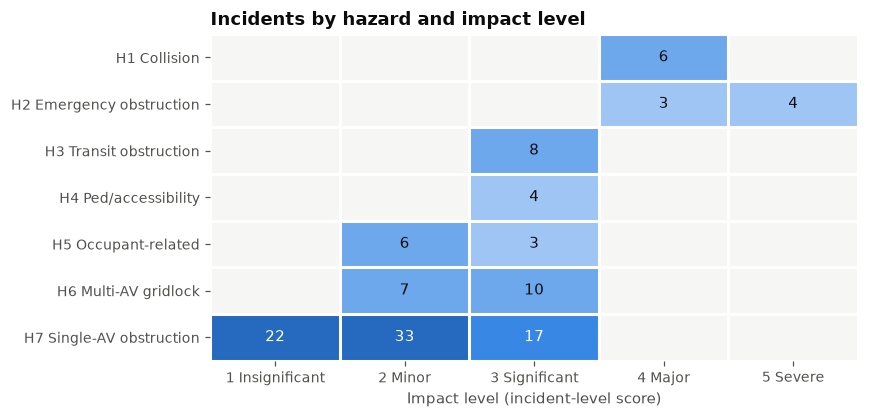

impact_driver
duration    63
hazard      55
cluster      5
Name: count, dtype: int64


In [14]:
rub = sv.rubric_table()
display(rub)
save_table(rub, "tbl-impact-rubric", "Incident-level impact rubric (the highest criterion met sets the level).")
hi = pd.crosstab(df.hazard, df.impact).reindex(index=tx.HAZARD_CODES, columns=range(1, 6), fill_value=0)
fig, _ = P.hazard_impact_heatmap(hi, [HAZ_LABEL[c] for c in tx.HAZARD_CODES],
                                 [f"{k} {sv.IMPACT_LABELS[k-1]}" for k in range(1, 6)])
save_fig(fig, "fig-hazard-impact"); plt.show()
print(df.impact_driver.value_counts())

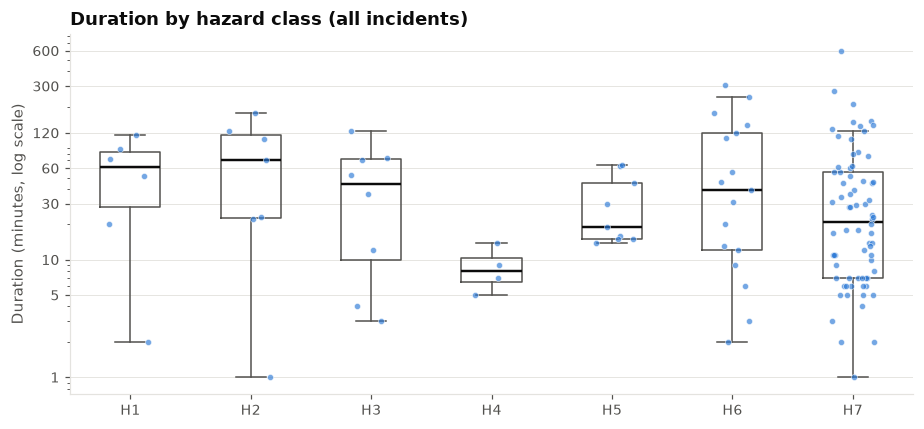

{'test': 'Kruskal-Wallis', 'H': 7.208584390177731, 'df': 6, 'p_value': 0.30198760320407253, 'epsilon_sq': 0.010418830949808026}


In [15]:
fig, _ = P.duration_by_group_plot(df, "hazard", tx.HAZARD_CODES, [c for c in tx.HAZARD_CODES],
                                  "Duration by hazard class (all incidents)")
save_fig(fig, "fig-duration-hazard"); plt.show()
kw_h = tr.kruskal_by(df.dropna(subset=["duration_min"]), "duration_min", "hazard", tx.HAZARD_CODES)
print(kw_h)
save_var("trend.kw_hazard_p", r(kw_h["p_value"], 3))

## 6. Frequency estimation

Incidents are modeled as a Poisson process with daily rate $\lambda$ over the
$T = 184$ covered days. The analysis reports:

* the MLE $\hat\lambda = n/T$ with an exact Garwood 95% CI;
* the Jeffreys-prior posterior $\lambda \mid n \sim \mathrm{Gamma}(n + \tfrac12,\ T)$
  with its 95% credible interval;
* the posterior-predictive probability of at least one event in the next $h = 30$ days,
  $P(N_h \ge 1) = 1 - \left(\frac{T}{T+h}\right)^{n + 1/2}$.

The log has no exposure denominator (AV trips or miles), so rates are **per calendar
day**. They describe the San Francisco system as operated in 2025, not per-mile safety.

**Why Bayesian for the risk matrix?** The matrix's probability axis is a statement about
*future* events: the chance of at least one in the next 30 days. The posterior predictive
answers that directly, and carries the large rate uncertainty of hazards with 3–6
incidents into the probability. A frequentist plug-in, $1-e^{-30\hat\lambda}$, treats the
estimated rate as exact and gives unseen hazards a probability of zero. The Jeffreys prior
encodes no opinion about AVs. The classical exact intervals are still reported, and
Section 9 shows the plug-in version yields the same placements, so the choice is
principled rather than decisive.

,hazard,name,n,share,rate_per_30d,ci_lo_30d,ci_hi_30d,post_mean_30d,cri_lo_30d,cri_hi_30d,mean_days_between,p_any_horizon,probability
0,H1,AV-involved collision,6,0.050,0.978,0.359,2.129,1.060,0.408,2.016,30.667,0.625,Likely
1,H2,Emergency-response obstruction,6,0.050,0.978,0.359,2.129,1.060,0.408,2.016,30.667,0.625,Likely
2,H3,Transit / rail obstruction,8,0.067,1.304,0.563,2.570,1.386,0.617,2.461,23.000,0.723,Likely
3,H4,Pedestrian / accessibility obstruction,4,0.033,0.652,0.178,1.670,0.734,0.220,1.551,46.000,0.493,Moderate
4,H5,Occupant-related immobilization,9,0.075,1.467,0.671,2.786,1.549,0.726,2.678,20.444,0.762,Likely
5,H6,Multi-AV clustering / gridlock,17,0.142,2.772,1.615,4.438,2.853,1.677,4.337,10.824,0.929,Almost certain
6,H7,Single-AV traffic obstruction,70,0.583,11.413,8.897,14.420,11.495,8.969,14.329,2.629,1.000,Almost certain
7,All,All blocking incidents,120,1.000,19.565,16.222,23.395,19.647,16.296,23.306,1.533,1.000,Almost certain


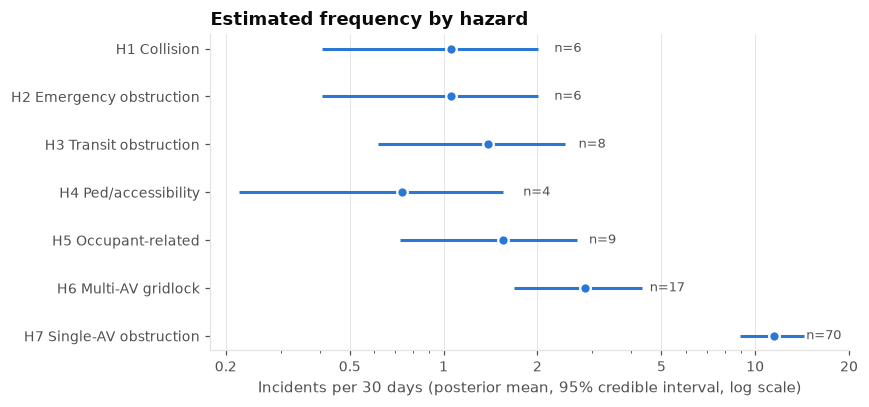

In [16]:
freq = fq.hazard_frequency_table(w, T)
show = freq[["hazard", "name", "n", "share", "rate_per_30d", "ci_lo_30d", "ci_hi_30d", "post_mean_30d",
             "cri_lo_30d", "cri_hi_30d", "mean_days_between", "p_any_horizon", "probability"]]
display(show.round(3))
tbl = show.assign(
    share=lambda d: d.share.map("{:.0%}".format),
    rate=lambda d: d.apply(lambda x: f"{x.rate_per_30d:.2f} ({x.ci_lo_30d:.2f}-{x.ci_hi_30d:.2f})", axis=1),
    post=lambda d: d.apply(lambda x: f"{x.post_mean_30d:.2f} ({x.cri_lo_30d:.2f}-{x.cri_hi_30d:.2f})", axis=1),
    every=lambda d: d.mean_days_between.map("{:.1f}".format),
    p=lambda d: d.p_any_horizon.map("{:.3f}".format),
)[["hazard", "name", "n", "share", "rate", "post", "every", "p", "probability"]]
tbl.columns = ["Code", "Hazard", "n", "Share", "MLE per 30 d (95% CI)", "Posterior per 30 d (95% CrI)",
               "Mean days between", "P(>=1 in 30 d)", "Band (all impacts)"]
save_table(tbl, "tbl-frequency", "Hazard frequencies over the 184 covered days (Mar, Jun-Oct 2025).")
tot = freq.set_index("hazard").loc["All"]
save_vars({"total_rate30": r(tot.rate_per_30d, 1), "total_lo": r(tot.ci_lo_30d, 1), "total_hi": r(tot.ci_hi_30d, 1),
           "days_between": r(tot.mean_days_between, 1), "per_week": r(tot.rate_per_30d / 30 * 7, 1)}, "freq")
for _, x in freq[freq.hazard != "All"].iterrows():
    save_vars({"n": int(x.n), "rate30": r(x.rate_per_30d), "every": r(x.mean_days_between, 0)}, f"freq.{x.hazard}")

fig, _ = P.hazard_rate_plot(freq, HAZ_LABEL)
save_fig(fig, "fig-hazard-rates"); plt.show()

## 7. Is anything changing over time?

Six monthly counts and about 120 skewed durations do not support normal-theory tests.
Each question is matched to a test whose assumptions hold here.

### 7.1 Incident counts

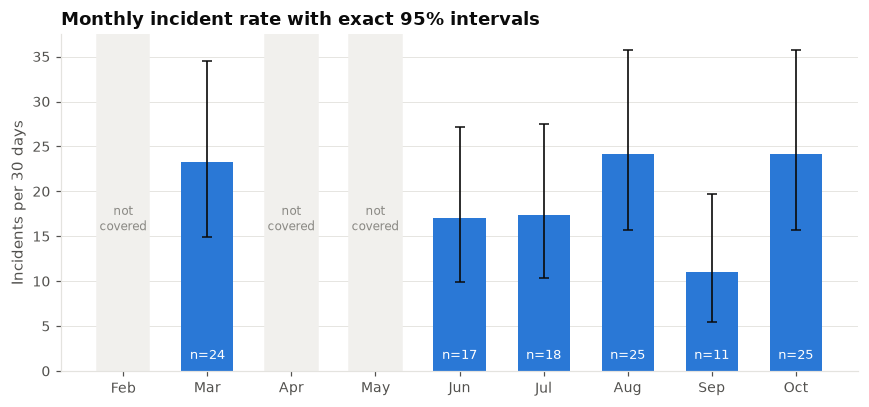

{'test': 'Poisson homogeneity (chi-square)', 'statistic': 7.299641577060934, 'df': 5, 'p_value': 0.1992922251810877}
{'test': 'Mann-Kendall', 'n': 6, 'S': 2.0, 'tau': 0.13333333333333333, 'z': np.float64(0.19127301391900148), 'p_normal': 0.8483117025202374, 'p_exact': 0.8555555555555555}
Sen slope (incidents/30d per month): 0.14
{'test': 'Exact conditional rate comparison', 'n1': 24, 'n2': 25, 'rate_ratio': 1.0416666666666667, 'rr_ci_lo': np.float64(0.5707914672791645), 'rr_ci_hi': np.float64(1.9048873947430458), 'p_value': 1.0}


,model,rate_ratio_per_month,ci_lo,ci_hi,p_value,pearson_dispersion,alpha
0,Poisson,0.9833,0.9097,1.0628,0.6715,1.82,NaN
1,Negative binomial (NB2),0.9835,0.9033,1.0708,0.7011,NaN,0.0105


In [17]:
mc = tr.monthly_counts(w, days)
ci = pd.DataFrame([fq.garwood_ci(n, d) for n, d in zip(mc.n, mc.days)], index=mc.index, columns=["lo", "hi"]) * 30
all_months = [str(p) for p in pd.period_range("2025-02", "2025-10", freq="M")]
fig, _ = P.monthly_rate_plot(mc, ci, all_months)
save_fig(fig, "fig-monthly-rate"); plt.show()

rate = (mc.n / mc.days).values
disp = tr.dispersion_test(mc.n, mc.days)
mk = tr.mann_kendall(rate)
sen = tr.sen_slope(rate * 30, mc.t)
mo = tr.exact_rate_comparison(int(mc.n.iloc[0]), 31, int(mc.n.iloc[-1]), 31)
glm = tr.count_glms(mc)
print(disp); print(mk); print("Sen slope (incidents/30d per month):", round(sen, 2)); print(mo)
display(glm.round(4))

### 7.2 Durations

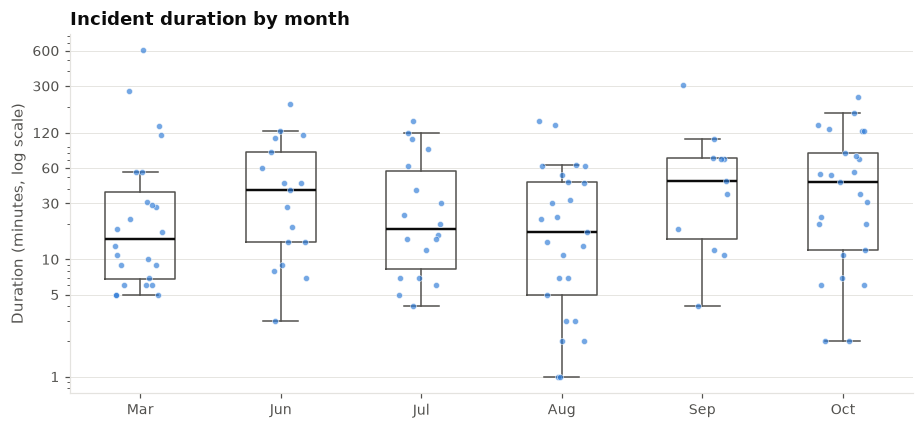

Kruskal-Wallis: {'test': 'Kruskal-Wallis', 'H': 6.884256507950153, 'df': 5, 'p_value': 0.2293916032884925, 'epsilon_sq': 0.016528565859211867}
Mann-Whitney Mar vs Oct: {'test': 'Mann-Whitney U', 'n1': 24, 'n2': 25, 'U': 222.5, 'p_value': 0.12323467768639308, 'rank_biserial': 0.2583333333333333, 'prob_superiority': 0.37083333333333335}
Replication without the 603-min outlier: U(Oct) = 377.5 p = 0.0645


Jonckheere-Terpstra: {'test': 'Jonckheere-Terpstra', 'JT': 3248.0, 'expected': 2960.0, 'z': 1.3242970930191955, 'p_value': 0.18589070546472677}
{'test': 'Spearman (duration vs date)', 'rho': 0.09717863061330638, 'p_value': 0.29101500650720047, 'theil_sen_pct_per_30d': 5.333591976411035, 'ts_lo_pct': -5.065471548094056, 'ts_hi_pct': 16.811511667700714}
Welch t on log durations Mar vs Oct: p = 0.245


In [18]:
order = list(days.index)
fig, _ = P.duration_by_group_plot(w, "month", order, [pd.Period(m).strftime("%b") for m in order],
                                  "Incident duration by month")
save_fig(fig, "fig-duration-month"); plt.show()

kw = tr.kruskal_by(w, "duration_min", "month", order)
mar = w.loc[w.month == "2025-03", "duration_min"]; octo = w.loc[w.month == "2025-10", "duration_min"]
mw = tr.mann_whitney(mar, octo)
# Replication of the instructor's sheet, which omitted the 603-minute Mar-12 record
mw_rep = tr.mann_whitney(mar[mar < 600], octo)
print("Kruskal-Wallis:", kw)
print("Mann-Whitney Mar vs Oct:", mw)
print("Replication without the 603-min outlier: U(Oct) =", 23 * 25 - mw_rep["U"], "p =", round(mw_rep["p_value"], 4))
jt = tr.jonckheere_terpstra([w.loc[w.month == m, "duration_min"].values for m in order])
print("Jonckheere-Terpstra:", jt)
dt_ = tr.duration_vs_time(w)
print(dt_)
# parametric cross-check on log scale (log-durations ~ normal)
from scipy import stats
print("Welch t on log durations Mar vs Oct: p =", round(stats.ttest_ind(np.log(mar), np.log(octo), equal_var=False).pvalue, 3))

### 7.3 Hazard mix and reporting artifacts

Hazard x period: {'test': 'Permutation chi-square', 'chi2': 16.42529087211434, 'p_value': 0.007149642517874106, 'share_expected_lt5': 0.7142857142857143}


period,Mar-Jul,Aug-Oct
hazard,,
H1,2,4
H2,0,6
H3,1,7
H4,4,0
H5,6,3
H6,9,8
H7,37,33


Truncated narratives by period:
 narrative_truncated  False  True 
period                           
Mar-Jul                  1     58
Aug-Oct                 36     25 
Fisher exact p = 4.982960875292966e-13
Median narrative length: {'Aug-Oct': 81.0, 'Mar-Jul': 50.0}
Text-dependent hazards (H1-H5) by period:
 hazard   False  True 
period               
Mar-Jul     46     13
Aug-Oct     41     20 
Fisher p = 0.22255362680504995
Multi-AV share trend (count field, not text): {'test': 'Cochran-Armitage', 'z': 1.3747338148189274, 'p_value': 0.16921398374150942}


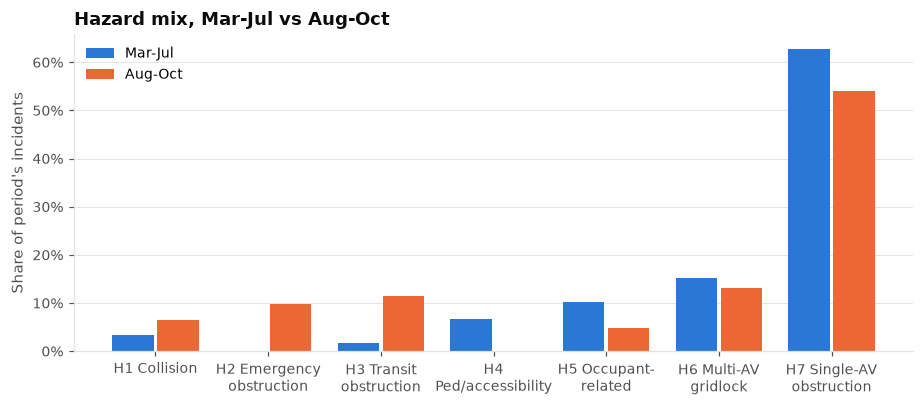

In [19]:
w["period"] = np.where(w.date < "2025-08-01", "Mar-Jul", "Aug-Oct")
mix = tr.permutation_chi2(w.hazard, w.period)
print("Hazard x period:", mix)
shares = pd.crosstab(w.hazard, w.period, normalize="columns")[["Mar-Jul", "Aug-Oct"]].reindex(tx.HAZARD_CODES)
display(pd.crosstab(w.hazard, w.period)[["Mar-Jul", "Aug-Oct"]])

trunc_tab = pd.crosstab(w.period, w.narrative_truncated).loc[["Mar-Jul", "Aug-Oct"]]
trunc = stats.fisher_exact(trunc_tab.values)
print("Truncated narratives by period:\n", trunc_tab, "\nFisher exact p =", trunc.pvalue)
mean_len = w.groupby("period")["narrative"].apply(lambda s: s.str.len().median())
print("Median narrative length:", mean_len.to_dict())

textual = w.hazard.isin(["H1", "H2", "H3", "H4", "H5"])
tx_tab = pd.crosstab(w.period, textual).loc[["Mar-Jul", "Aug-Oct"]]
tx_p = stats.fisher_exact(tx_tab.values).pvalue
print("Text-dependent hazards (H1-H5) by period:\n", tx_tab, "\nFisher p =", tx_p)

mca = tr.monthly_counts(w, days, "multi_av")
ca = tr.cochran_armitage(mca[True], mca[True] + mca[False], mca.t)
print("Multi-AV share trend (count field, not text):", ca)

fig, _ = P.grouped_share_plot(shares, [HAZ_LABEL[c] for c in tx.HAZARD_CODES],
                              "Hazard mix, Mar-Jul vs Aug-Oct", "Share of period's incidents")
save_fig(fig, "fig-hazard-period"); plt.show()

The hazard mix *does* differ between periods (permutation p ≈ 0.007). But the change is a
reshuffle *within* the text-dependent classes. H2 (emergency) and H3 (transit) appear almost
only from August on, while H4 and H5 were more common earlier. The combined share of H1–H5
does not differ (Fisher p ≈ 0.22). The narratives changed at the same moment: 98% of Mar–Jul
narratives are truncated fragments (median 50 characters), against 41% for Aug–Oct (median
81). Context such as "fire", "medic", or "Muni" is exactly what a 50-character fragment
loses. The one composition measure that comes from a structured field, the multi-AV share,
shows no trend (Cochran–Armitage p ≈ 0.17). The defensible conclusion is that the observed
shift is **not attributable** to a change in AV behavior. It is most plausibly a
reporting/recording artifact.

In [20]:
tests = pd.DataFrame([
    ["Monthly incident rate", "Equal rate across months", "Poisson homogeneity chi-square",
     f"chi2({disp['df']}) = {disp['statistic']:.2f}", disp["p_value"]],
    ["Monthly incident rate", "No monotone trend", "Mann-Kendall (exact)",
     f"S = {mk['S']:.0f}, tau = {mk['tau']:.2f}", mk["p_exact"]],
    ["Monthly incident rate", "Mar rate = Oct rate", "Exact conditional binomial",
     f"RR = {mo['rate_ratio']:.2f} ({mo['rr_ci_lo']:.2f}-{mo['rr_ci_hi']:.2f})", mo["p_value"]],
    ["Monthly incident rate", "No log-linear trend", "Poisson GLM, log(days) offset",
     f"RR/month = {glm.rate_ratio_per_month[0]:.3f} ({glm.ci_lo[0]:.3f}-{glm.ci_hi[0]:.3f})", glm.p_value[0]],
    ["Duration", "Same distribution in all months", "Kruskal-Wallis",
     f"H({kw['df']}) = {kw['H']:.2f}, eps2 = {kw['epsilon_sq']:.3f}", kw["p_value"]],
    ["Duration", "Mar = Oct", "Mann-Whitney U", f"U = {mw['U']:.1f}, r_rb = {mw['rank_biserial']:.2f}", mw["p_value"]],
    ["Duration", "Mar = Oct (603-min record dropped, replicates class sheet)", "Mann-Whitney U",
     f"W = {23 * 25 - mw_rep['U']:.1f}", mw_rep["p_value"]],
    ["Duration", "No ordered shift across months", "Jonckheere-Terpstra (permutation)",
     f"JT = {jt['JT']:.0f}, z = {jt['z']:.2f}", jt["p_value"]],
    ["Duration", "No association with date", "Spearman; Theil-Sen on log duration",
     f"rho = {dt_['rho']:.2f}; {dt_['theil_sen_pct_per_30d']:+.1f}%/30 d ({dt_['ts_lo_pct']:+.1f} to {dt_['ts_hi_pct']:+.1f})",
     dt_["p_value"]],
    ["Hazard mix", "Independent of period", "Permutation chi-square", f"chi2 = {mix['chi2']:.2f}", mix["p_value"]],
    ["Narrative truncation", "Independent of period", "Fisher exact",
     f"{trunc_tab.loc['Mar-Jul', True] / trunc_tab.loc['Mar-Jul'].sum():.0%} vs {trunc_tab.loc['Aug-Oct', True] / trunc_tab.loc['Aug-Oct'].sum():.0%} truncated", trunc.pvalue],
    ["Text-dependent hazards (H1-H5) share", "Independent of period", "Fisher exact",
     f"{tx_tab.loc['Mar-Jul', True] / tx_tab.loc['Mar-Jul'].sum():.0%} vs {tx_tab.loc['Aug-Oct', True] / tx_tab.loc['Aug-Oct'].sum():.0%}", tx_p],
    ["Multi-AV share", "No monotone trend", "Cochran-Armitage", f"z = {ca['z']:.2f}", ca["p_value"]],
], columns=["Quantity", "Null hypothesis", "Test", "Statistic / effect", "p"])
tests["Reject at 0.05?"] = np.where(tests.p < 0.05, "Yes", "No")
tests["p"] = tests.p.map(fmt_p)
display(tests)
save_table(tests, "tbl-tests", "Statistical tests for change over time (covered months).")
save_vars({"disp_p": r(disp["p_value"], 2), "mk_p": r(mk["p_exact"], 2), "mk_tau": r(mk["tau"], 2),
           "mo_rr": r(mo["rate_ratio"]), "mo_lo": r(mo["rr_ci_lo"]), "mo_hi": r(mo["rr_ci_hi"]), "mo_p": r(mo["p_value"], 2),
           "glm_rr": r(glm.rate_ratio_per_month[0], 3), "glm_lo": r(glm.ci_lo[0], 3), "glm_hi": r(glm.ci_hi[0], 3),
           "glm_p": r(glm.p_value[0], 2), "glm_disp": r(glm.pearson_dispersion[0], 2),
           "kw_H": r(kw["H"]), "kw_p": r(kw["p_value"], 2), "mw_p": r(mw["p_value"], 3),
           "mw_rep_W": float(23 * 25 - mw_rep["U"]), "mw_rep_p": r(mw_rep["p_value"], 3),
           "jt_p": r(jt["p_value"], 2), "rho": r(dt_["rho"]), "rho_p": r(dt_["p_value"], 2),
           "ts_pct": r(dt_["theil_sen_pct_per_30d"], 1), "ts_lo": r(dt_["ts_lo_pct"], 1), "ts_hi": r(dt_["ts_hi_pct"], 1),
           "mix_p": r(mix["p_value"], 3), "tx_p": r(tx_p, 2), "trunc_p": fmt_p(trunc.pvalue), "ca_p": r(ca["p_value"], 2),
           "trunc_early": f"{trunc_tab.loc['Mar-Jul', True] / trunc_tab.loc['Mar-Jul'].sum():.0%}",
           "trunc_late": f"{trunc_tab.loc['Aug-Oct', True] / trunc_tab.loc['Aug-Oct'].sum():.0%}"}, "trend")

,Quantity,Null hypothesis,Test,Statistic / effect,p,Reject at 0.05?
0,Monthly incident rate,Equal rate across months,Poisson homogeneity chi-square,chi2(5) = 7.30,0.199,No
1,Monthly incident rate,No monotone trend,Mann-Kendall (exact),"S = 2, tau = 0.13",0.856,No
2,Monthly incident rate,Mar rate = Oct rate,Exact conditional binomial,RR = 1.04 (0.57-1.90),1.000,No
3,Monthly incident rate,No log-linear trend,"Poisson GLM, log(days) offset",RR/month = 0.983 (0.910-1.063),0.671,No
4,Duration,Same distribution in all months,Kruskal-Wallis,"H(5) = 6.88, eps2 = 0.017",0.229,No
5,Duration,Mar = Oct,Mann-Whitney U,"U = 222.5, r_rb = 0.26",0.123,No
6,Duration,"Mar = Oct (603-min record dropped, replicates class sheet)",Mann-Whitney U,W = 377.5,0.064,No
7,Duration,No ordered shift across months,Jonckheere-Terpstra (permutation),"JT = 3248, z = 1.32",0.186,No
8,Duration,No association with date,Spearman; Theil-Sen on log duration,rho = 0.10; +5.3%/30 d (-5.1 to +16.8),0.291,No
9,Hazard mix,Independent of period,Permutation chi-square,chi2 = 16.43,0.007,Yes


## 8. Risk matrix

**Probability band.** $p = P(N_{30} \ge 1)$ from the posterior predictive above, banded
with the template's edges: Rare < 0.05 ≤ Unlikely < 0.25 ≤ Moderate < 0.50 ≤ Likely < 0.90 ≤
Almost certain.

**Impact and placement (risk curve).** For hazard $h$ and impact tier $k$, count
$n_{h,\ge k}$, the incidents of $h$ with impact $\ge k$. Each observed tier yields a
candidate cell $\big(\text{band}(n_{h,\ge k}),\,k\big)$. The hazard sits in the candidate
cell with the highest template risk level (ties go to the higher impact). Probability and
impact then describe the same event ("an $h$ incident of at least impact $k$"). Only tiers
that actually occurred are considered.

,Hazard,Impact tier k,n with impact >= k,P(>=1 in 30 d),Probability,Risk level
0,H1,1 Insignificant,6,0.625,Likely,Medium
1,H1,2 Minor,6,0.625,Likely,Medium
2,H1,3 Significant,6,0.625,Likely,High
3,H1,4 Major,6,0.625,Likely,Very high
0,H2,1 Insignificant,6,0.625,Likely,Medium
1,H2,2 Minor,6,0.625,Likely,Medium
2,H2,3 Significant,6,0.625,Likely,High
3,H2,4 Major,6,0.625,Likely,Very high
4,H2,5 Severe,3,0.411,Moderate,Very high
0,H3,1 Insignificant,8,0.723,Likely,Medium


,hazard,name,n,median_impact,max_impact,governing_impact,n_at_or_above,p_any_horizon,prob,impact_label,prob_label,level,score
0,H1,AV-involved collision,6,4,4,4,6,0.625349,4,Major,Likely,Very high,16
1,H2,Emergency-response obstruction,6,4,5,5,3,0.410595,3,Severe,Moderate,Very high,15
2,H3,Transit / rail obstruction,8,3,3,3,8,0.723029,4,Significant,Likely,High,12
3,H4,Pedestrian / accessibility obstruction,4,3,3,3,4,0.493221,3,Significant,Moderate,Medium,9
4,H5,Occupant-related immobilization,9,2,3,3,3,0.410595,3,Significant,Moderate,Medium,9
5,H6,Multi-AV clustering / gridlock,17,3,3,3,10,0.795241,4,Significant,Likely,High,12
6,H7,Single-AV traffic obstruction,70,2,3,3,17,0.928867,5,Significant,Almost certain,Very high,15


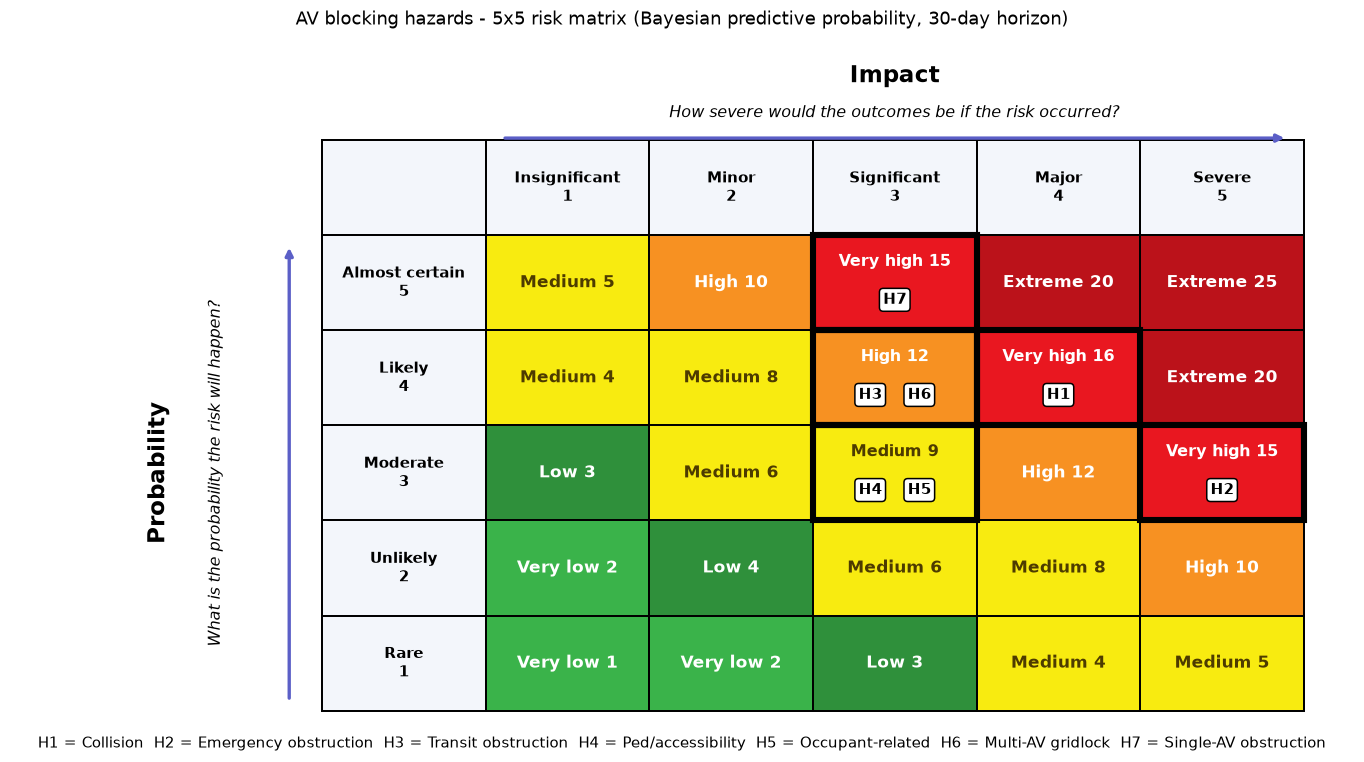

In [21]:
curves = pd.concat([fq.risk_curve(w, h, T) for h in tx.HAZARD_CODES])
curves_tbl = curves.assign(p_any=curves.p_any.round(3),
                           prob=curves.prob.map(lambda b: rm.PROB_LABELS[b - 1]),
                           impact=curves.impact.map(lambda k: f"{k} {sv.IMPACT_LABELS[k-1]}"))
curves_tbl.columns = ["Hazard", "Impact tier k", "n with impact >= k", "P(>=1 in 30 d)", "Probability", "Risk level"]
display(curves_tbl)
save_table(curves_tbl, "tbl-risk-curves", "Risk-curve candidates: each observed impact tier with its own frequency and risk level.")

placed = fq.place_hazards(w, T)
display(placed)
pt = placed.assign(p=placed.p_any_horizon.map("{:.2f}".format),
                   prob=placed.apply(lambda x: f"{x.prob} {x.prob_label}", axis=1),
                   imp=placed.apply(lambda x: f"{x.governing_impact} {x.impact_label}", axis=1),
                   lvl=placed.apply(lambda x: f"{x.level} ({x.score})", axis=1))[
    ["hazard", "name", "n", "n_at_or_above", "p", "prob", "imp", "lvl"]]
pt.columns = ["Code", "Hazard", "n", "n at governing impact", "P(>=1 in 30 d)", "Probability", "Impact", "Risk level (score)"]
save_table(pt, "tbl-risk-placement", "Risk-matrix placement of each hazard (Bayesian predictive probability, 30-day horizon).")
for x in placed.itertuples():
    save_vars({"level": x.level, "prob": x.prob_label, "impact": x.impact_label, "score": x.score,
               "n_ge": x.n_at_or_above, "p": r(x.p_any_horizon, 2)}, f"risk.{x.hazard}")

fig, _ = rm.plot_risk_matrix(fq.to_placements(placed),
                             title="AV blocking hazards - 5x5 risk matrix (Bayesian predictive probability, 30-day horizon)",
                             footnote="  ".join(f"{h.code} = {h.short}" for h in tx.HAZARDS))
save_fig(fig, "fig-risk-matrix"); plt.show()

**Two kinds of red.** The matrix puts hazards with very different profiles in the same band.
H1 (collision) and H2 (emergency obstruction) are *consequence-driven*: they happen about
monthly, but each one can harm people or delay emergency care. H7 (single-AV obstruction)
is *volume-driven*: no single incident is worse than an hour-long traffic delay, but those
happen about every 11 days, so a *Significant* blockage is almost certain in any month.
Both readings are "Very high", but they call for different responses. H1 and H2 are safety
problems; H7 is an operational problem (recovery speed). Risk matrices are known to blur
this distinction [Cox 2008], which is why the rates and risk curves are reported alongside
each cell.

## 9. Sensitivity analysis

How far do the placements move under reasonable alternative choices?

* **Probability basis**: plug-in MLE instead of the Bayesian predictive.
* **Horizon**: 7 or 90 days instead of 30.
* **Exposure window**: include February. This treats Feb 1–Mar 31 and Jun 1–Oct 31 as
  observed (212 days, all 123 incidents).
* **Supplementary incidents**: add the analyzed-sheet incidents that have a narrative
  but no times. They are classified by the same rules and given impact from hazard and
  AV count only.
* **Placement rule**: the conventional pairing of total hazard frequency with the
  90th-percentile impact.
* **Label source**: hazards labeled by the manual audit, or by the best pretrained model
  (embedding similarity), instead of the rules. Impact is re-scored, because it depends on
  the hazard.

In [22]:
def cell(p):
    return p.set_index("hazard").apply(lambda x: f"{x.prob}x{x.governing_impact} {x.level}", axis=1)

sens = pd.DataFrame({"Base (Bayesian, 30 d, covered months)": cell(placed)})
sens["Plug-in MLE"] = cell(fq.place_hazards(w, T, basis="per_period"))
sens["7-day horizon"] = cell(fq.place_hazards(w, T, horizon=7))
sens["90-day horizon"] = cell(fq.place_hazards(w, T, horizon=90))
sens["Include February (212 d)"] = cell(fq.place_hazards(df, 212.0))

sp = supp.copy()
sp["in_covered_window"] = sp.month.isin(config.COVERED_MONTHS)
sp["hazard"] = [tx.classify_hazard(t, n) for t, n in zip(sp.narrative, sp.n_avs_filled)]
sp["impact"] = [max(sv.hazard_score(h, t), sv.cluster_score(n)) for h, t, n in zip(sp.hazard, sp.narrative, sp.n_avs_filled)]
w_plus = pd.concat([w[["hazard", "impact"]], sp.loc[sp.in_covered_window, ["hazard", "impact"]]])
sens["+ supplementary incidents"] = cell(fq.place_hazards(w_plus, T))
conv = fq.conventional_placement(w, T).set_index("hazard")
sens["Total freq x P90 impact"] = conv.apply(lambda x: f"{x.prob}x{x.impact} {x.level}", axis=1)
# Label source: would a different hazard labeler move the placements?
# Re-score impact (it depends on hazard) and re-place using each alternative label set.
def relabeled(labels):
    d = sv.score_incidents(df.assign(hazard=labels))
    return cell(fq.place_hazards(d[d.in_covered_window], T))

sens["Manual audit labels"] = relabeled(df["manual_hazard"].values)
emb_name = nlp.PRETRAINED_MODELS["embedding"]["name"]
if emb_name in pretrained:
    sens["Embedding-model labels"] = relabeled(pretrained[emb_name])
sens.index = [HAZ_LABEL[c] for c in sens.index]
display(sens)
save_table(sens.reset_index(names="Hazard"), "tbl-sensitivity",
           "Sensitivity of risk-matrix placement (cell shown as probability x impact and level).")
print(sp[["date", "hazard", "impact", "narrative"]])

,"Base (Bayesian, 30 d, covered months)",Plug-in MLE,7-day horizon,90-day horizon,Include February (212 d),+ supplementary incidents,Total freq x P90 impact,Manual audit labels,Embedding-model labels
H1 Collision,4x4 Very high,4x4 Very high,2x4 Medium,5x4 Extreme,4x4 Very high,4x4 Very high,4x4 Very high,4x4 Very high,4x4 Very high
H2 Emergency obstruction,3x5 Very high,3x5 Very high,2x5 High,4x5 Extreme,3x5 Very high,3x5 Very high,4x5 Extreme,3x5 Very high,3x5 Very high
H3 Transit obstruction,4x3 High,4x3 High,3x3 Medium,5x3 Very high,4x3 High,4x3 High,4x3 High,4x3 High,5x3 Very high
H4 Ped/accessibility,3x3 Medium,3x3 Medium,2x3 Medium,4x3 High,3x3 Medium,3x3 Medium,3x3 Medium,3x3 Medium,4x3 High
H5 Occupant-related,3x3 Medium,3x3 Medium,2x3 Medium,4x3 High,3x3 Medium,3x3 Medium,4x3 High,3x3 Medium,3x3 Medium
H6 Multi-AV gridlock,4x3 High,4x3 High,3x3 Medium,5x3 Very high,4x3 High,4x3 High,5x3 Very high,4x3 High,4x3 High
H7 Single-AV obstruction,5x3 Very high,5x3 Very high,3x3 Medium,5x3 Very high,5x3 Very high,5x3 Very high,5x3 Very high,5x3 Very high,4x3 High


        date hazard  impact                                                                                                      narrative
0 2025-02-01     H4       3  Req from CHP to have SFPD resp to assist with removing disabled Waymo AV that is completely blocking the r...
1 2025-08-15     H7       1  RP reporting an unoccpyd Zoox AV driving erratically, had its left turn signal on but kept turning right a...
2 2025-10-15     H7       1                                                           Waymo blking traffic rep on 911 txd to 0123 non-emer
3 2025-10-16     H7       1                                                               Waymo AV drove into the middle of active 518 H/R
4 2025-10-20     H3       3                                                          Two Muni Coaches stuck in traffic per RP it is due to
5 2025-10-22     H2       4                                                            Multi veh inj accident Waymo AV drove into the scen
6 2025-10-31     H7       1

#### How much does the *Significant* duration threshold matter?

The rubric calls a blockage *Significant* at 60 minutes. That threshold is a judgment call,
and it mainly drives H7 and H6. Below, every incident is re-scored with the threshold at 60,
90, 120, and 180 minutes, and every hazard is re-placed. The 10-minute *Minor* threshold
and all other rubric criteria are held fixed. This shows how the 60-minute choice drives
the result; it does not replace the base case, which was fixed before placement.

In [23]:
thr_rows = {}
for thr in [60, 90, 120, 180]:
    d = sv.score_incidents(df, duration_edges=(10, thr))
    thr_rows[f"Significant at >= {thr} min"] = cell(fq.place_hazards(d[d.in_covered_window], T))
thr_sens = pd.DataFrame(thr_rows)
h7 = w[w.hazard == "H7"]
thr_sens.loc["H7 incidents at/above threshold"] = [str(int((h7.duration_min >= t).sum())) for t in [60, 90, 120, 180]]
thr_sens.index = [HAZ_LABEL.get(c, c) for c in thr_sens.index]
display(thr_sens)
save_table(thr_sens.reset_index(names="Hazard"), "tbl-threshold-sensitivity",
           "Risk-matrix placement when the duration threshold for a Significant impact is raised (all incidents re-scored; base case 60 minutes).")
save_vars({f"h7_{t}": thr_sens.loc[HAZ_LABEL["H7"], f"Significant at >= {t} min"].split(" ", 1)[1]
           for t in [60, 90, 120, 180]}, "thr")
save_vars({f"h7_n{t}": int((h7.duration_min >= t).sum()) for t in [60, 90, 120, 180]}, "thr")

,Significant at >= 60 min,Significant at >= 90 min,Significant at >= 120 min,Significant at >= 180 min
H1 Collision,4x4 Very high,4x4 Very high,4x4 Very high,4x4 Very high
H2 Emergency obstruction,3x5 Very high,3x5 Very high,3x5 Very high,3x5 Very high
H3 Transit obstruction,4x3 High,4x3 High,4x3 High,4x3 High
H4 Ped/accessibility,3x3 Medium,3x3 Medium,3x3 Medium,3x3 Medium
H5 Occupant-related,3x3 Medium,3x3 Medium,3x3 Medium,3x3 Medium
H6 Multi-AV gridlock,4x3 High,4x3 High,4x3 High,4x3 High
H7 Single-AV obstruction,5x3 Very high,4x3 High,4x3 High,5x2 High
H7 incidents at/above threshold,17,11,9,3


**How to read the sensitivity table.**

* **Robust to data choices.** Placements do not move under the MLE basis, when February is
  included, or when the supplementary incidents are added.
* **Robust to the labeler.** Labeling hazards with the manual audit instead of the rules
  gives *identical* placements, so the matrix does not depend on rule errors. Labeling
  with the embedding model moves transit (H3) and pedestrian/accessibility (H4) up one
  band and H7 down one band. That reflects the embedding model's known over-prediction of
  H3 and H4 (see the classifier comparison), not a fragile matrix.
* **The horizon sets the absolute level.** A 7-day horizon lowers every hazard one or two
  bands; a 90-day horizon raises them. The horizon is a *policy* choice: 30 days matches a
  monthly operations-review cycle. The *ranking* is stable: under every column, H2 is at (or tied for) the
  highest level and H5 at (or tied for) the lowest. H4 is also at or tied for the lowest
  everywhere except the embedding-label column.
* **The duration threshold matters for H7.** H7 is *Very high* only because a 60-minute
  blockage counts as *Significant*. At a threshold of 90 minutes or more it drops to *High*
  and stays there, even at 180 minutes, because routine 10-minute-plus blockages make it
  Almost certain × Minor (threshold table below). Every other hazard keeps its cell: H1-H5
  get their impact from the consequence type, and H6 mostly from clusters of 5+ AVs.
* **The placement rule matters for H2.** The conventional "total frequency × P90 impact"
  rule puts H2 at *Extreme*. That pairs H2's overall frequency (6 events) with its rarer
  life-threatening tier (3 events), which overstates the probability of the Severe outcome.
  The risk-curve method avoids that inconsistency, which is why it is the base case.

In [24]:
headline = (
    f"Over {int(T)} covered days the DEM log records {len(w)} AV blocking incidents, about "
    f"{tot.rate_per_30d:.1f} per 30 days (one every {tot.mean_days_between:.1f} days). "
    f"Neither the incident rate nor incident duration shows a statistically significant trend. "
    f"On the risk matrix, " + "; ".join(f"{x.hazard} ({x.name}) is **{x.level}**" for x in placed.itertuples()) + "."
)
save_text(headline, "headline")
display(Markdown(headline))

Over 184 covered days the DEM log records 120 AV blocking incidents, about 19.6 per 30 days (one every 1.5 days). Neither the incident rate nor incident duration shows a statistically significant trend. On the risk matrix, H1 (AV-involved collision) is **Very high**; H2 (Emergency-response obstruction) is **Very high**; H3 (Transit / rail obstruction) is **High**; H4 (Pedestrian / accessibility obstruction) is **Medium**; H5 (Occupant-related immobilization) is **Medium**; H6 (Multi-AV clustering / gridlock) is **High**; H7 (Single-AV traffic obstruction) is **Very high**.